# **Artificial Neural Networks and Deep Learning**

---

## **Pirate: Timeseries Classification**


## 🌐 **Google Drive Connection**

In [1]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/[2025-2026]\\ AN2DL/Challenge\\ 1"
%cd $current_dir

Mounted at /gdrive
[Errno 2] No such file or directory: '/gdrive/My Drive/[2025-2026] AN2DL/Challenge 1'
/content


## ⚙️ **Libraries Import**

In [2]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import WeightedRandomSampler
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [3]:
# Download dataset files in the directory
!gdown https://drive.google.com/uc?id=1-1y4Ew8MWOCEBBSxislxPJrXRw6QHod- -O /content/pirate_pain_train.csv
!gdown https://drive.google.com/uc?id=1wrwCG5ujY22-r9xHccpPFwRk_-FZBVH9 -O /content/pirate_pain_train_labels.csv
!gdown https://drive.google.com/uc?id=1r5SfJLw4Quw-9QlbVfAChKDS7j3PPDNK -O /content/pirate_pain_test.csv


Downloading...
From: https://drive.google.com/uc?id=1-1y4Ew8MWOCEBBSxislxPJrXRw6QHod-
To: /content/pirate_pain_train.csv
100% 63.7M/63.7M [00:00<00:00, 229MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wrwCG5ujY22-r9xHccpPFwRk_-FZBVH9
To: /content/pirate_pain_train_labels.csv
100% 8.16k/8.16k [00:00<00:00, 34.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1r5SfJLw4Quw-9QlbVfAChKDS7j3PPDNK
From (redirected): https://drive.google.com/uc?id=1r5SfJLw4Quw-9QlbVfAChKDS7j3PPDNK&confirm=t&uuid=3bfcc457-6d61-4391-9ac3-174dc45422ac
To: /content/pirate_pain_test.csv
100% 131M/131M [00:01<00:00, 119MB/s] 


In [4]:
import pandas as pd

df = pd.read_csv("/content/pirate_pain_train.csv")
target = pd.read_csv("/content/pirate_pain_train_labels.csv")
test = pd.read_csv("/content/pirate_pain_test.csv")


print(df.shape)
print(target.shape)

target.head(10)
df.head(10)

(105760, 40)
(661, 2)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


## 🔎 **Exploration and Data Analysis**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

In [6]:
df.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746147e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800090e-06,3.079465e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


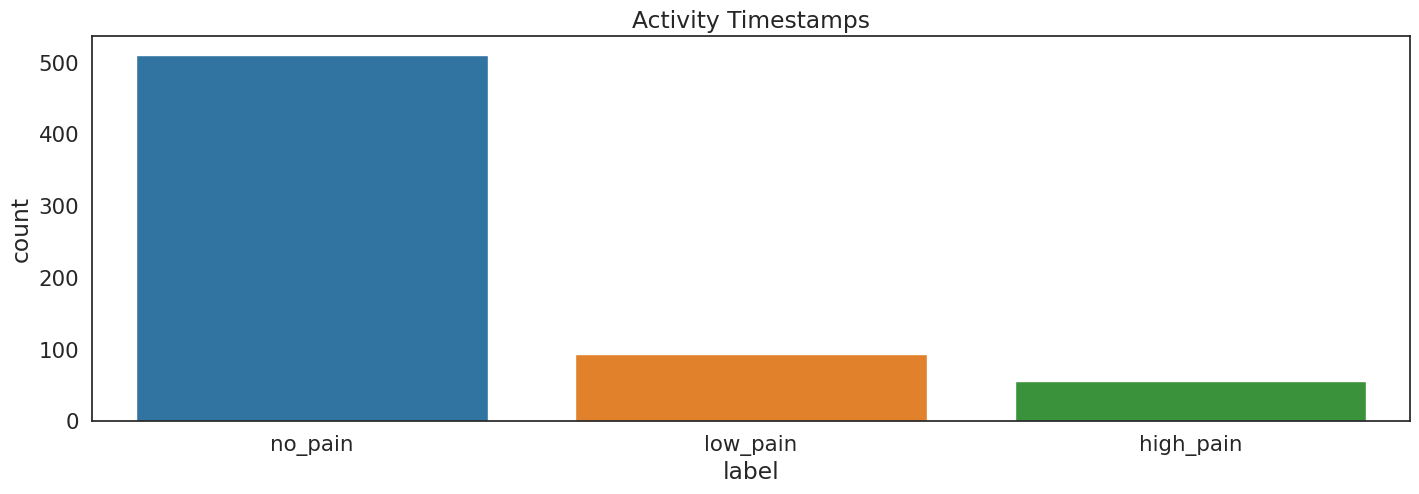

n_legs
two            104800
one+peg_leg       960
Name: count, dtype: int64
n_hands
two              104800
one+hook_hand       960
Name: count, dtype: int64
n_eyes
two              104800
one+eye_patch       960
Name: count, dtype: int64


In [7]:
# Visualise the count of each pain state
plt.figure(figsize=(17, 5))
sns.countplot(
    x='label',
    data=target,
    order=target['label'].value_counts().index,
    palette='tab10'
)

# Set the title of the plot
plt.title('Activity Timestamps')

# Display the plot
plt.show()

print(df['n_legs'].value_counts())
print(df['n_hands'].value_counts())
print(df['n_eyes'].value_counts())
df_dummies=pd.get_dummies(df, columns=['n_legs', 'n_hands', 'n_eyes'])



In [8]:
# Count the number of unique users
n_pirates = len(df['sample_index'].unique())
print(f"Number of unique users: {n_pirates}")

measurement_counts = df.groupby('sample_index').size()
print(measurement_counts)

Number of unique users: 661
sample_index
0      160
1      160
2      160
3      160
4      160
      ... 
656    160
657    160
658    160
659    160
660    160
Length: 661, dtype: int64


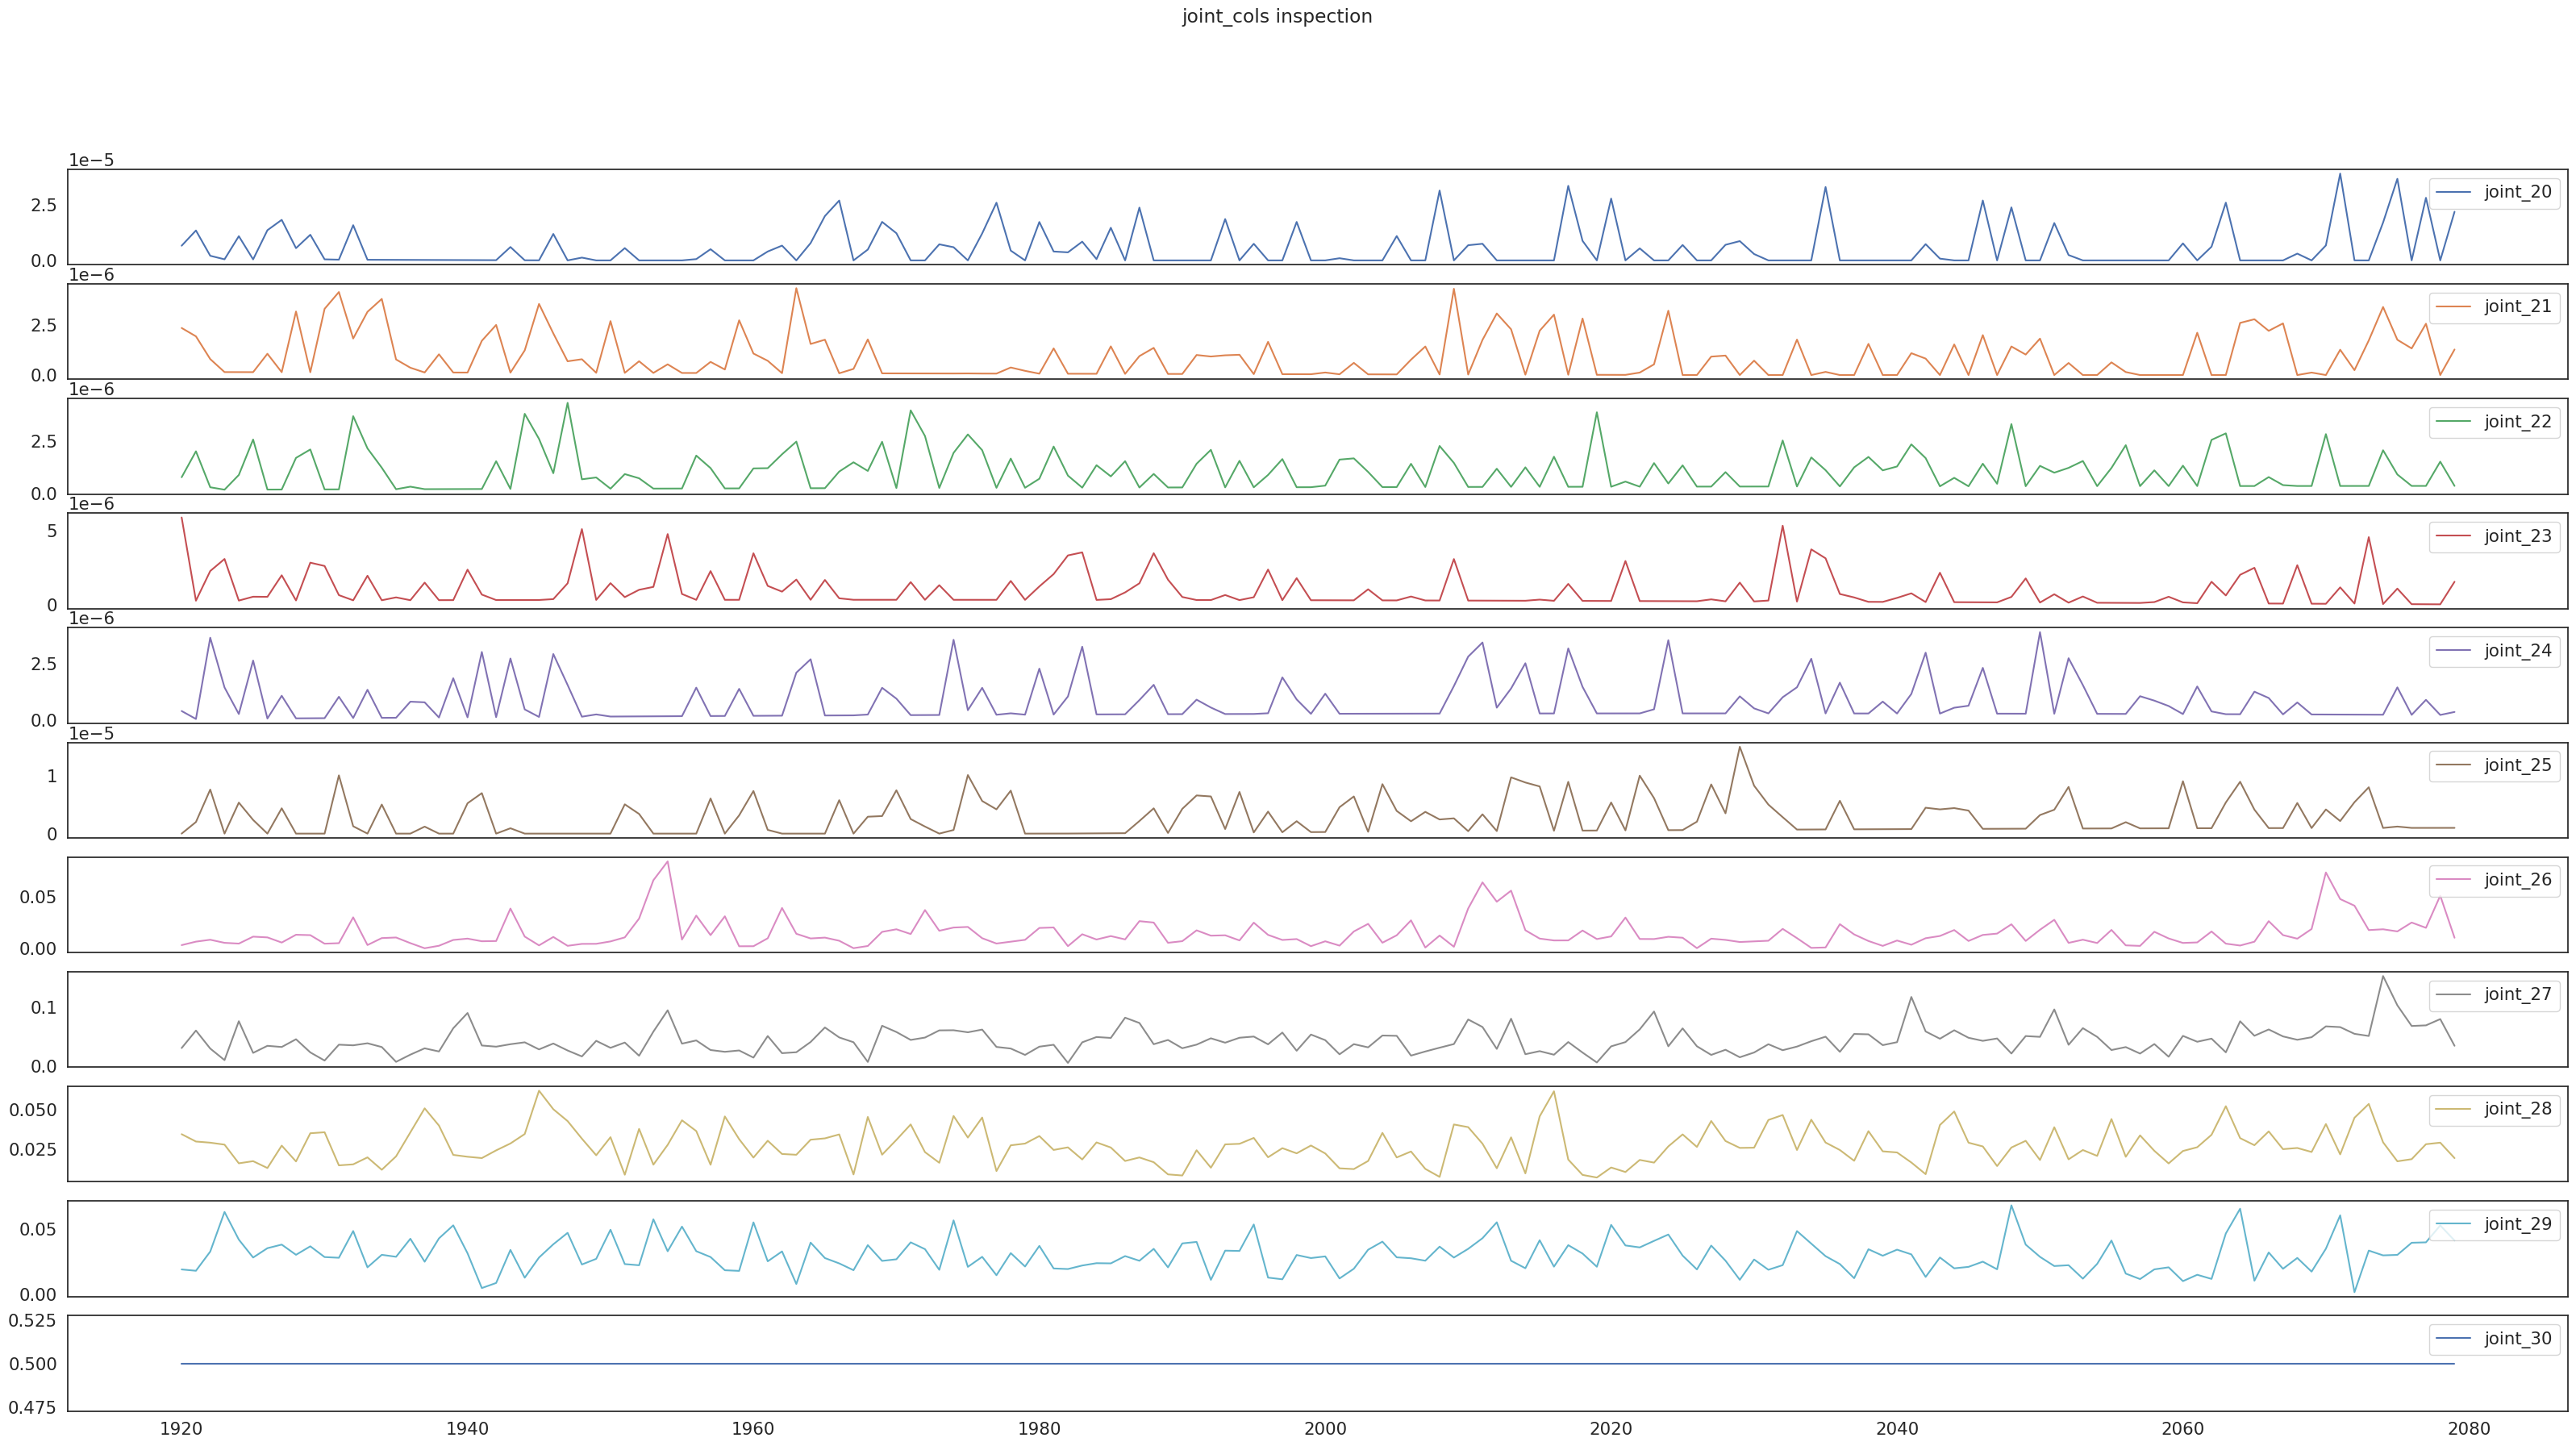

In [9]:
# Show columns' trends
idx= 12
joint_cols1 = [col for col in df.columns if col.startswith('joint_2')]
joint_cols2 = [col for col in df.columns if col.startswith('joint_3')]
joint_cols = joint_cols1+joint_cols2

axis = (df[df['sample_index'] == idx][joint_cols]).plot(subplots=True, figsize=(40, 20), title="joint_cols inspection")
for ax in axis:
    ax.legend(loc='upper right')

,sample_index,label
12,12,no_pain


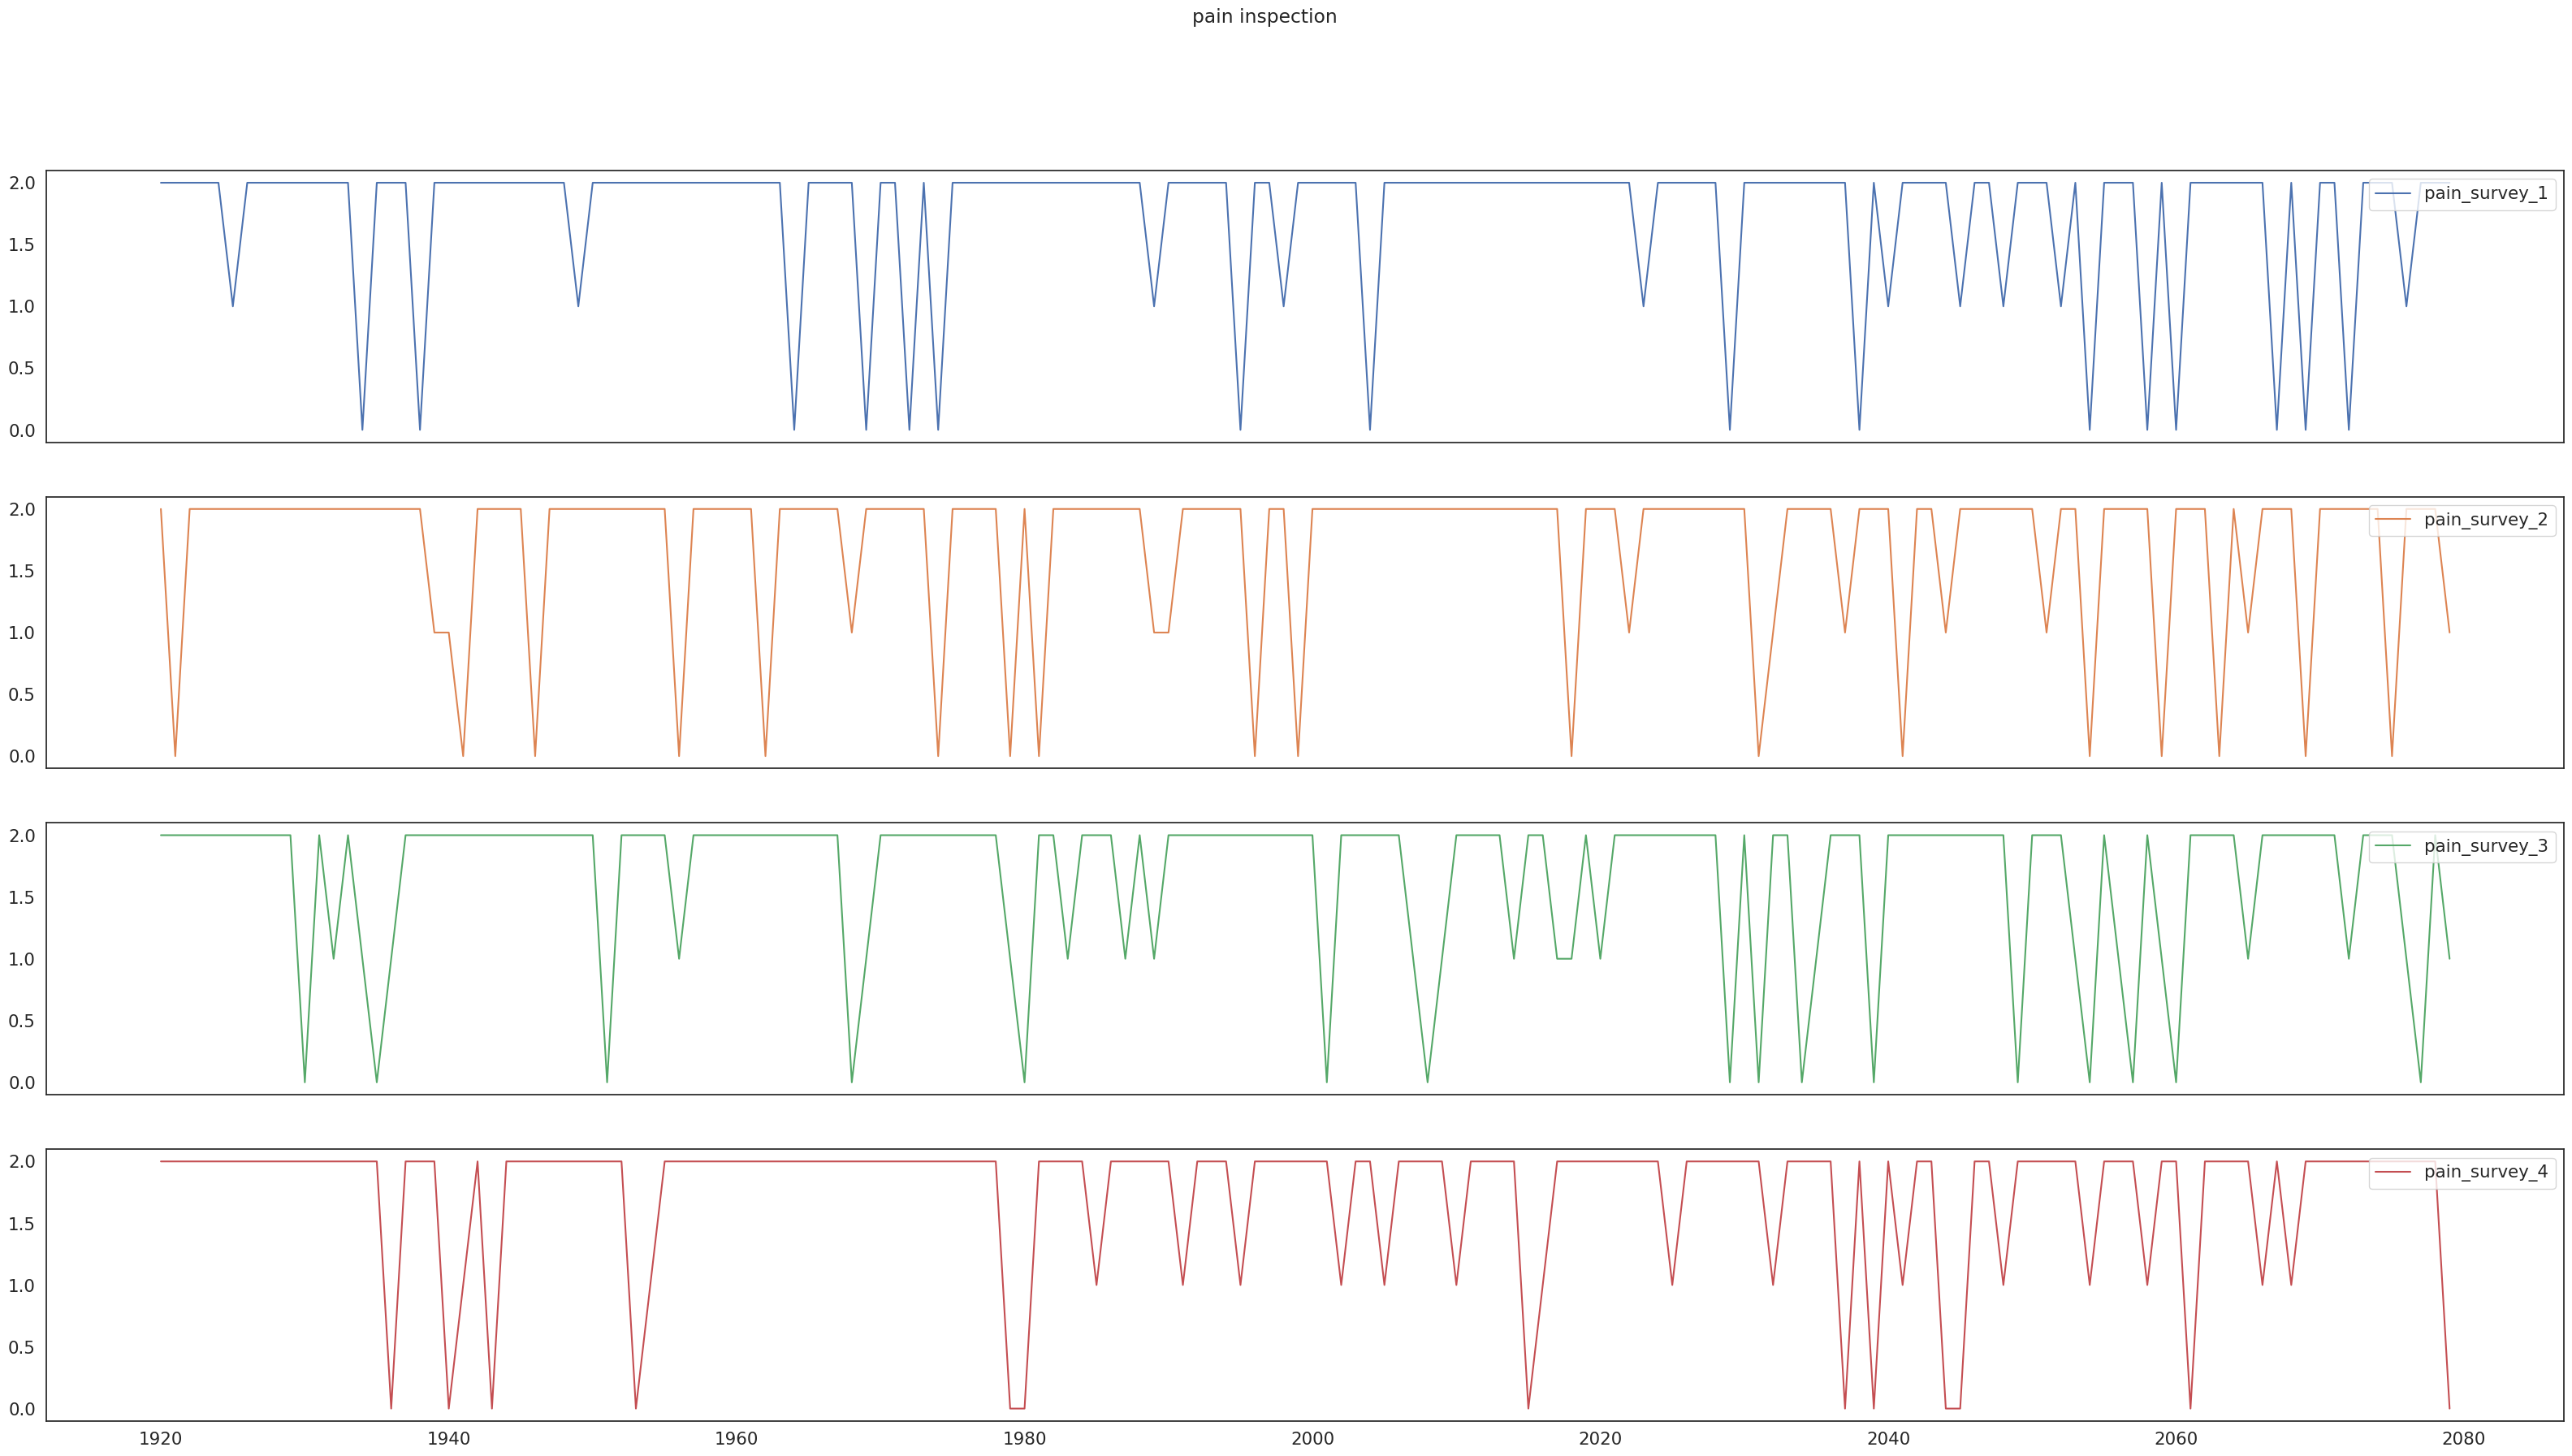

In [10]:
# Show columns' trends
joint_cols = [col for col in df.columns if col.startswith('pain')]

axis = (df[df['sample_index'] == idx][joint_cols]).plot(subplots=True, figsize=(40, 20), title="pain inspection")
for ax in axis:
    ax.legend(loc='upper right')

target[target['sample_index'] == idx]

<Figure size 1200x600 with 0 Axes>

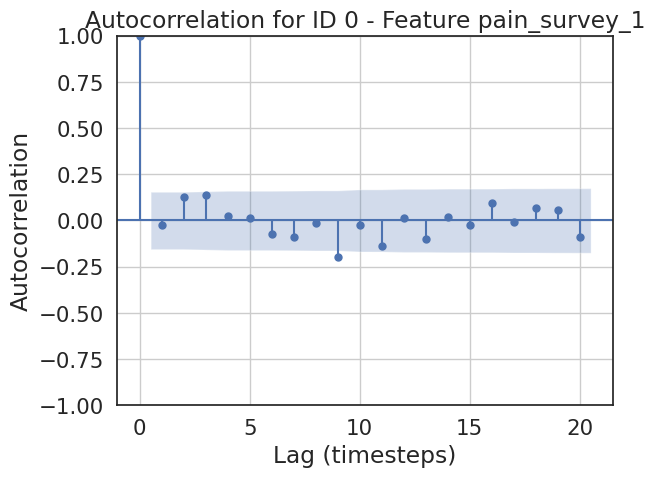

Autocorrelation plot saved to 'autocorrelation.png'


In [11]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# --- Parameters to Change ---
user_id = 0       # Pick a user ID to analyze
feature = 'pain_survey_1'     # Pick a feature (e.g., 'X', 'Y', 'Z')
max_lags = 20    # How far back to check.
                  # Your window in cell [25] was 100, so let's check further.
# ----------------------------

# Extract the timeseries for one user and one feature
series = df[df['sample_index'] == user_id][feature]

# Create the plot
plt.figure(figsize=(12, 6))
plot_acf(series, lags=max_lags, title=f'Autocorrelation for ID {user_id} - Feature {feature}')
plt.xlabel('Lag (timesteps)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.savefig('autocorrelation.png') # Save the plot
plt.show()

print(f"Autocorrelation plot saved to 'autocorrelation.png'")

## 🔄 **Data Preprocessing**

In [12]:
# Define a function to build sequences from the dataset
def build_sequences(df, target=None, window=40, stride=20):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset_X_seq = [] # joint + pain survey
    dataset_X_static = [] #n_leg ...
    labels = []
    ids = []
    j_cols = [col for col in df.columns if col.startswith('joint_')]
    p_cols = [col for col in df.columns if col.startswith('pain_survey_')]


    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp1 = df[df['sample_index'] == id][j_cols].values
        temp2 = df[df['sample_index'] == id][p_cols].values
        temp = np.concatenate((temp1, temp2), axis=1)

        static = df[df['sample_index'] == id][['n_legs', 'n_hands', 'n_eyes']].iloc[0].values
        if target is not None:
          label = target[target['sample_index'] == id]['label'].values

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        if padding_len > 0:
            padding = np.zeros((padding_len, temp.shape[1]), dtype='float64')
            temp = np.concatenate((temp, padding), axis=0)

        # Build feature windows and associate them with labels
        idx = 0

        while idx + window <= len(temp):
            dataset_X_seq.append(temp[idx:idx + window])
            dataset_X_static.append(static)
            ids.append(id)
            if target is not None:
              labels.append(label)
            idx += stride


    # Convert lists to numpy arrays for further processing
    dataset_X_seq = np.array(dataset_X_seq)
    dataset_X_static = np.array(dataset_X_static)
    # Return the built sequences and their corresponding label
    if target is not None:
      labels = np.array(labels)

    return dataset_X_seq, dataset_X_static, labels, ids

In [13]:
# Define a function to build sequences from the dataset
def build_sequences2(df, target=None, window=40, stride=20):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset_X_seq = [] # joint + pain survey
    dataset_X_static = [] #n_leg ...
    labels = []
    ids = []
    j_cols = [col for col in df.columns if col.startswith('joint_')]
    p_cols = [col for col in df.columns if col.startswith('pain_survey_')]
    t_cols = [col for col in df.columns if col.startswith('tim')]
    cols = j_cols+ p_cols


    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp = df[df['sample_index'] == id][cols].values

        static = df[df['sample_index'] == id][['n_legs_one+peg_leg', 'n_legs_two',
    'n_hands_one+hook_hand', 'n_hands_two',
    'n_eyes_one+eye_patch', 'n_eyes_two']].iloc[0].values
        if target is not None:
          label = target[target['sample_index'] == id]['label'].values

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        if padding_len > 0:
            padding = np.zeros((padding_len, temp.shape[1]), dtype='float64')
            temp = np.concatenate((temp, padding), axis=0)

        # Build feature windows and associate them with labels
        idx = 0

        while idx + window <= len(temp):
            dataset_X_seq.append(temp[idx:idx + window])
            dataset_X_static.append(static)
            ids.append(id)
            if target is not None:
              labels.append(label)
            idx += stride


    # Convert lists to numpy arrays for further processing
    dataset_X_seq = np.array(dataset_X_seq)
    dataset_X_static = np.array(dataset_X_static)
    # Return the built sequences and their corresponding label
    if target is not None:
      labels = np.array(labels)

    return dataset_X_seq, dataset_X_static, labels, ids

In [14]:
def make_loader(ds, batch_size, shuffle, drop_last, sampler=None):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))
    if sampler is not None:
        shuffle = False
    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
        sampler=sampler
    )

In [15]:
class AugmentedDataset():
    def __init__(self, X, y, augment=False, noise_level=0.01):
        """
        X: Input tensor or array
        y: Target tensor or array
        augment: Boolean, whether to apply noise
        noise_level: Standard deviation of the Gaussian noise
        """
        self.X = X
        self.y = y
        self.augment = augment
        self.noise_level = noise_level

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample = self.X[idx]
        label = self.y[idx]

        # Apply Augmentation ONLY if enabled (for training)
        if self.augment:
            # Create random noise with same shape as sample
            noise = torch.randn_like(sample) * self.noise_level
            sample = sample + noise

        return sample, label

## 🛠️ **Model Building**

In [16]:
# @title Recurrent summary
def recurrent_summary(model, input_size):
    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [17]:
# @title RecurrentClassifier
class RecurrentClassifier(nn.Module):

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits






## 🧮 **Network and Training Hyperparameters**

In [18]:
N_VAL_USERS = 100         # Number of users for validation split
N_TEST_USERS = 0

# Training
EPOCHS = 200             # Maximum epochs (increase to improve performance)
PATIENCE = 15            # Early stopping patience (increase to improve performance)
VERBOSE = 1             # Print frequency

# Optimisation
LEARNING_RATE = 1e-4   # Learning rate
BATCH_SIZE = 64         # Batch size
WINDOW_SIZE = 30      # Input window size
STRIDE = 2       # Input stride

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.4      # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA =0.0001           # L2 penalty

# Move the weights tensor to the GPU
class_counts = target['label'].value_counts()
weights = 1/class_counts
weights = weights/weights.mean()
weights = torch.tensor(weights.values, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)
weights

tensor([0.1928, 1.0480, 1.7592], device='cuda:0')

In [19]:
best_model = None
best_performance = float('-inf')
gru_performance = float('-inf')
lstm_performance = float('-inf')
bigru_performance = float('-inf')
bilstm_performance = float('-inf')

## 🔄 **Data Preprocessing OverSampling**




In [ ]:
df = pd.read_csv("/content/pirate_pain_train.csv")
target = pd.read_csv("/content/pirate_pain_train_labels.csv")
test = pd.read_csv("/content/pirate_pain_test.csv")

# Define a mapping of activity names to integer labels
df = pd.get_dummies(df)
test = pd.get_dummies(test)


df = df.drop(columns=['joint_30'])
df = df.drop(columns=['time'])

test = test.drop(columns=['joint_30'])
test = test.drop(columns=['time'])

j_cols = [col for col in df.columns if col.startswith('joint_')]
p_cols = [col for col in df.columns if col.startswith('pain_survey_')]

df[j_cols] = df[j_cols].astype('float32')
cols_to_normalize = j_cols + p_cols

# Get unique user IDs and shuffle them with split-specific seed
unique_users = df['sample_index'].unique()
random.seed(SEED)
random.shuffle(unique_users)

# Calculate the number of users for the training set
n_train_users = len(unique_users) - N_VAL_USERS - N_TEST_USERS

# Split the shuffled user IDs into training, validation, and test sets
train_users = unique_users[:n_train_users]
val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]
test_users = unique_users[n_train_users + N_VAL_USERS:]

# Split the dataset into training, validation, and test sets based on user IDs
df_train = df[df['sample_index'].isin(train_users)].copy()
df_val = df[df['sample_index'].isin(val_users)].copy()
target_train = target[target['sample_index'].isin(train_users)].copy()
target_val = target[target['sample_index'].isin(val_users)].copy()

# Define a mapping of activity names to integer labels
label_mapping = {
  'no_pain': 0,
  'low_pain': 1,
  'high_pain': 2
}

# Map activity names to integers in the training set
target_train['label'] = target_train['label'].map(label_mapping)

# Map activity names to integers in the validation set
target_val['label'] = target_val['label'].map(label_mapping)

# Normalise features using training set statistics
j_cols = [col for col in df.columns if col.startswith('joint_')]
p_cols = [col for col in df.columns if col.startswith('pain_survey_')]


cols_to_normalize = j_cols + p_cols
mins = df_train[cols_to_normalize].min()
maxs = df_train[cols_to_normalize].max()

for column in cols_to_normalize:
  df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])
  test[column] = (test[column] - mins[column]) / (maxs[column] - mins[column])



# Build sequences using the existing build_sequences function
# Ensure X_train_static_tiled, X_val_static_tiled, X_test_static_tiled are defined outside or recalculated
X_train_seq, X_train_static, y_train, X_train_seq_ids = build_sequences2(df_train, target_train, WINDOW_SIZE, STRIDE)
X_val_seq, X_val_static,  y_val, X_val_seq_ids = build_sequences2(df_val, target_val, WINDOW_SIZE, STRIDE)
# Note: 'test' DataFrame doesn't have a target, so the label will be None, which is handled in build_sequences
X_test_seq, X_test_static, _, test_ids = build_sequences2(test, None, WINDOW_SIZE, STRIDE)

# Re-tiling static features as they depend on the current split's data
X_train_static_tiled_split = np.repeat(X_train_static[:, None, :], X_train_seq.shape[1], axis=1)
X_val_static_tiled_split   = np.repeat(X_val_static[:, None, :],   X_val_seq.shape[1], axis=1)
X_test_static_tiled_split  = np.repeat(X_test_static[:, None, :],  X_test_seq.shape[1], axis=1)

X_train = np.concatenate([X_train_seq, X_train_static_tiled_split], axis=2)
X_val   = np.concatenate([X_val_seq,   X_val_static_tiled_split],   axis=2)
X_test = np.concatenate([X_test_seq,  X_test_static_tiled_split],  axis=2)

print(f"  Training sequences shape: {X_train.shape}")
print(f"  Validation sequences shape: {X_val.shape}")
print(f"  Test sequences shape: {X_test.shape}")

input_shape= X_train.shape[1:]
input_size= input_shape[-1]

# Convert numpy arrays to tensors first
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).squeeze().long()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).squeeze().long()

X_test_tensor = torch.from_numpy(X_test).float()

# -> Use AugmentedDataset for Training (augment=True)
# noise_level=0.01 adds a small amount of jitter to the data
train_ds = AugmentedDataset(X_train_tensor, y_train_tensor, augment=True, noise_level=0.1)

# -> Use standard TensorDataset for Validation and Test (augment=False implicitly)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)
test_ds = TensorDataset(X_test_tensor)

class_weights=[1,5.55,9.25] # These are the weights for classes 0, 1, 2

# Create sample weights for each sequence in the training set based on its label
y_train_flat = y_train.flatten()
sample_weights = np.array([class_weights[label_val] for label_val in y_train_flat])
weights_tensor = torch.from_numpy(sample_weights).double()

# Create the WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=weights_tensor,
    num_samples=len(weights_tensor),
    replacement=True  # Set to True to oversample
)

# Create data loaders
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, sampler=sampler)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


  Training sequences shape: (18513, 40, 40)
  Validation sequences shape: (3300, 40, 40)
  Test sequences shape: (43692, 40, 40)


Plotting histograms for 4 batches...
Histogram saved as: batch_label_distribution.png


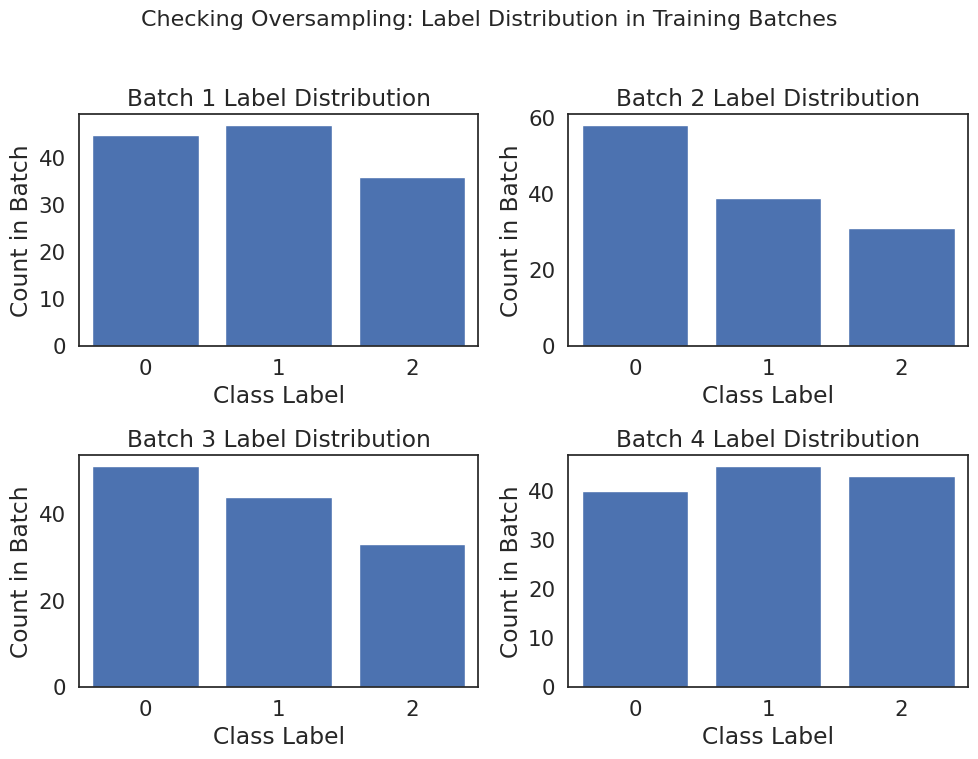

In [ ]:
# @title Batch view

# --- Configuration ---
num_batches_to_check = 4 # We'll create a 2x2 grid of plots
num_cols = 2
num_rows = (num_batches_to_check + num_cols - 1) // num_cols # Calculate rows needed
# ---------------------

# Create an iterator for the train_loader
data_iter = iter(train_loader)

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, num_rows * 4))

# Flatten axes array for easy iteration
if num_batches_to_check > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Handle single plot case

print(f"Plotting histograms for {num_batches_to_check} batches...")

# Bins are set to center the bars on the integer labels 0, 1, 2
# Bins: -0.5 to 0.5 (for 0), 0.5 to 1.5 (for 1), 1.5 to 2.5 (for 2)
bins = np.arange(-0.5, 3, 1)

for i in range(num_batches_to_check):
    try:
        # Get the next batch
        _, y_batch = next(data_iter)

        # Select the correct subplot
        ax = axes[i]

        # Squeeze, move to CPU, and convert to NumPy
        labels = y_batch.squeeze().cpu().numpy()

        # Plot the histogram
        ax.hist(labels, bins=bins, rwidth=0.8, align='mid')

        # --- Formatting ---
        ax.set_title(f"Batch {i + 1} Label Distribution")
        ax.set_xlabel("Class Label")
        ax.set_ylabel("Count in Batch")

        # Set X-axis ticks to be exactly 0, 1, 2
        ax.set_xticks([0, 1, 2])
        ax.set_xlim(-0.5, 2.5) # Set x-limits to match bins

    except StopIteration:
        print(f"Only {i} batches were available in the loader.")
        # Hide any unused subplots
        for j in range(i, len(axes)):
            axes[j].axis('off')
        break

# Hide any remaining unused subplots if the loop finished early
for j in range(num_batches_to_check, len(axes)):
    axes[j].axis('off')

# Add a main title for the whole figure
fig.suptitle("Checking Oversampling: Label Distribution in Training Batches", fontsize=16)

# Improve layout
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect to make space for suptitle

# Save the figure
plot_filename = "batch_label_distribution.png"
plt.savefig(plot_filename)

print(f"Histogram saved as: {plot_filename}")
# You should see the plot output directly in your notebook



## 🔄 **Data Preprocessing 2**


In [20]:
df = pd.read_csv("/content/pirate_pain_train.csv")
target = pd.read_csv("/content/pirate_pain_train_labels.csv")

test = pd.read_csv("/content/pirate_pain_test.csv")


df = pd.get_dummies(df)
test = pd.get_dummies(test)

df = df.drop(columns=['joint_30'])


test = test.drop(columns=['joint_30'])

j_cols = [col for col in df.columns if col.startswith('joint_')]
p_cols = [col for col in df.columns if col.startswith('pain_survey_')]
t_cols = [col for col in df.columns if col.startswith('tim')]


df[j_cols] = df[j_cols].astype('float32')
cols_to_normalize = j_cols + p_cols + t_cols

# Get unique user IDs and shuffle them with split-specific seed

unique_users = df['sample_index'].unique()
random.seed(SEED)
random.shuffle(unique_users)

# Calculate the number of users for the training set

n_train_users = len(unique_users) - N_VAL_USERS - N_TEST_USERS

# Split the shuffled user IDs into training, validation, and test sets
train_users = unique_users[:n_train_users]
val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]
test_users = unique_users[n_train_users + N_VAL_USERS:]

# Split the dataset into training, validation, and test sets based on user IDs
df_train = df[df['sample_index'].isin(train_users)].copy()
df_val = df[df['sample_index'].isin(val_users)].copy()
target_train = target[target['sample_index'].isin(train_users)].copy()
target_val = target[target['sample_index'].isin(val_users)].copy()

# Define a mapping of activity names to integer labels
label_mapping = {
  'no_pain': 0,
  'low_pain': 1,
  'high_pain': 2
}

# Map activity names to integers in the training set
target_train['label'] = target_train['label'].map(label_mapping)

# Map activity names to integers in the validation set
target_val['label'] = target_val['label'].map(label_mapping)

# Normalise features using training set statistics

mins = df_train[cols_to_normalize].min()
maxs = df_train[cols_to_normalize].max()

for column in cols_to_normalize:
  df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])
  test[column] = (test[column] - mins[column]) / (maxs[column] - mins[column])
  df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])


# Build sequences using the existing build_sequences function
# Ensure X_train_static_tiled, X_val_static_tiled, X_test_static_tiled are defined outside or recalculated
X_train_seq, X_train_static, y_train, X_train_seq_ids = build_sequences2(df_train, target_train, WINDOW_SIZE, STRIDE)
X_val_seq, X_val_static,  y_val, X_val_seq_ids = build_sequences2(df_val, target_val, WINDOW_SIZE, STRIDE)
# Note: 'test' DataFrame doesn't have a target, so the label will be None, which is handled in build_sequences
X_test_seq, X_test_static, _, test_ids = build_sequences2(test, None, WINDOW_SIZE, STRIDE)

# Re-tiling static features as they depend on the current split's data
X_train_static_tiled_split = np.repeat(X_train_static[:, None, :], X_train_seq.shape[1], axis=1)
X_val_static_tiled_split   = np.repeat(X_val_static[:, None, :],   X_val_seq.shape[1], axis=1)
X_test_static_tiled_split  = np.repeat(X_test_static[:, None, :],  X_test_seq.shape[1], axis=1)

X_train = np.concatenate([X_train_seq, X_train_static_tiled_split], axis=2)
X_val   = np.concatenate([X_val_seq,   X_val_static_tiled_split],   axis=2)
X_test = np.concatenate([X_test_seq,  X_test_static_tiled_split],  axis=2)

print(f"  Training sequences shape: {X_train.shape}")
print(f"  Validation sequences shape: {X_val.shape}")
print(f"  Test sequences shape: {X_test.shape}")

input_shape= X_train.shape[1:]
input_size= input_shape[-1]

# Create PyTorch datasets
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).squeeze().long())
val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).squeeze().long())
test_ds = TensorDataset(torch.from_numpy(X_test).float())

# Create data loaders
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

target_train['label'].value_counts()


  Training sequences shape: (42636, 30, 40)
  Validation sequences shape: (7600, 30, 40)
  Test sequences shape: (100624, 30, 40)


,count
label,
0,435
1,79
2,47


Plotting histograms for 4 batches...
Histogram saved as: batch_label_distribution.png


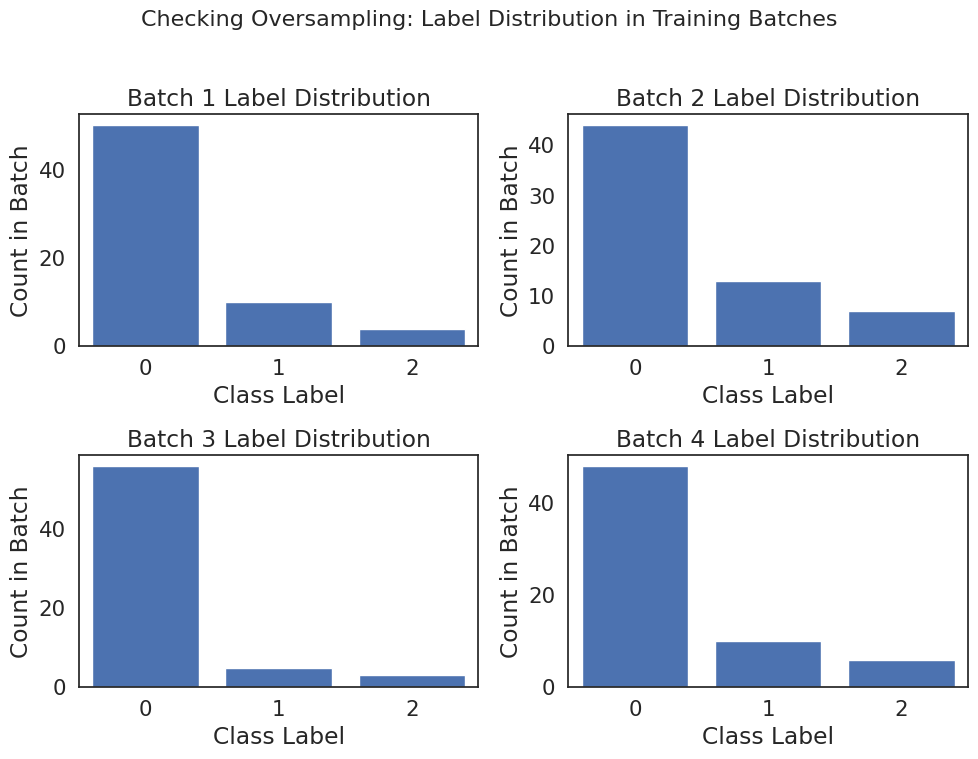

In [21]:

# --- Configuration ---
num_batches_to_check = 4 # We'll create a 2x2 grid of plots
num_cols = 2
num_rows = (num_batches_to_check + num_cols - 1) // num_cols # Calculate rows needed
# ---------------------

# Create an iterator for the train_loader
data_iter = iter(train_loader)

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, num_rows * 4))

# Flatten axes array for easy iteration
if num_batches_to_check > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Handle single plot case

print(f"Plotting histograms for {num_batches_to_check} batches...")

# Bins are set to center the bars on the integer labels 0, 1, 2
# Bins: -0.5 to 0.5 (for 0), 0.5 to 1.5 (for 1), 1.5 to 2.5 (for 2)
bins = np.arange(-0.5, 3, 1)

for i in range(num_batches_to_check):
    try:
        # Get the next batch
        _, y_batch = next(data_iter)

        # Select the correct subplot
        ax = axes[i]

        # Squeeze, move to CPU, and convert to NumPy
        labels = y_batch.squeeze().cpu().numpy()

        # Plot the histogram
        ax.hist(labels, bins=bins, rwidth=0.8, align='mid')

        # --- Formatting ---
        ax.set_title(f"Batch {i + 1} Label Distribution")
        ax.set_xlabel("Class Label")
        ax.set_ylabel("Count in Batch")

        # Set X-axis ticks to be exactly 0, 1, 2
        ax.set_xticks([0, 1, 2])
        ax.set_xlim(-0.5, 2.5) # Set x-limits to match bins

    except StopIteration:
        print(f"Only {i} batches were available in the loader.")
        # Hide any unused subplots
        for j in range(i, len(axes)):
            axes[j].axis('off')
        break

# Hide any remaining unused subplots if the loop finished early
for j in range(num_batches_to_check, len(axes)):
    axes[j].axis('off')

# Add a main title for the whole figure
fig.suptitle("Checking Oversampling: Label Distribution in Training Batches", fontsize=16)

# Improve layout
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect to make space for suptitle

# Save the figure
plot_filename = "batch_label_distribution.png"
plt.savefig(plot_filename)

print(f"Histogram saved as: {plot_filename}")
# You should see the plot output directly in your notebook



## 🧠 **Model Training**

In [22]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [23]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [24]:
def train_one_epoch_emb(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for x_seq, x_static, y in train_loader:
        # Move data to device (GPU/CPU)
        x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(x_seq, x_static)
            loss = criterion(logits, y)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * x_seq.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(y.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [25]:
def validate_one_epoch_emb(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for x_seq, x_static, y in val_loader:

          # Move data to device
          x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)

          # Forward pass with mixed precision (if CUDA available)
          with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
              logits = model(x_seq, x_static)
              loss = criterion(logits, y)

          # Accumulate metrics
          running_loss += loss.item() *  x_seq.size(0)
          predictions = logits.argmax(dim=1)
          all_predictions.append(predictions.cpu().numpy())
          all_targets.append(y.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [26]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [27]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="",scheduler = None):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )
        if scheduler:
             # Get the metric to monitor (e.g., 'val_f1' or 'val_loss')
             metric_to_monitor = training_history['val_loss'][-1]
             scheduler.step(metric_to_monitor)


        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [28]:
def fit_emb(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler = None):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch_emb(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch_emb(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )
        if scheduler:
          # Get the metric to monitor (e.g., 'val_f1' or 'val_loss')
          metric_to_monitor = training_history['val_loss'][-1]
          scheduler.step(metric_to_monitor)

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## 🧠 **Model RNN**

In [29]:
# @title
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=3,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "rnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 30, 128], [2, -1, 128]] 54,784         
classifier (Linear)       [-1, 3]                      387            
Total params: 55,171
Trainable params: 55,171
Non-trainable params: 0
-------------------------------------------------------------------------------


In [30]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="bi_rnn",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if max(training_history['val_f1']) > best_performance:
    best_model = rnn_model
    best_performance = max(training_history['val_f1'])

modelbirnn = rnn_model

Training 200 epochs...
Epoch   1/200 | Train: Loss=1.1805, F1 Score=0.4597 | Val: Loss=1.4151, F1 Score=0.5299
Epoch   2/200 | Train: Loss=1.0917, F1 Score=0.6083 | Val: Loss=1.3176, F1 Score=0.7048
Epoch   3/200 | Train: Loss=1.0053, F1 Score=0.7221 | Val: Loss=1.2638, F1 Score=0.7927
Epoch   4/200 | Train: Loss=0.8911, F1 Score=0.8188 | Val: Loss=1.1646, F1 Score=0.8552
Epoch   5/200 | Train: Loss=0.8627, F1 Score=0.8453 | Val: Loss=1.1532, F1 Score=0.8548
Epoch   6/200 | Train: Loss=0.8453, F1 Score=0.8567 | Val: Loss=1.1356, F1 Score=0.8808
Epoch   7/200 | Train: Loss=0.8335, F1 Score=0.8587 | Val: Loss=1.1768, F1 Score=0.8547
Epoch   8/200 | Train: Loss=0.8168, F1 Score=0.8675 | Val: Loss=1.1415, F1 Score=0.8535
Epoch   9/200 | Train: Loss=0.8036, F1 Score=0.8724 | Val: Loss=1.1406, F1 Score=0.8697
Epoch  10/200 | Train: Loss=0.7894, F1 Score=0.8762 | Val: Loss=1.1273, F1 Score=0.8709
Epoch  11/200 | Train: Loss=0.7839, F1 Score=0.8777 | Val: Loss=1.1525, F1 Score=0.8576
Epoch  12

## 🧠 **Model LSTM**

In [31]:
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=3,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "LSTM"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 30, 128], [2, -1, 128]] 219,136        
classifier (Linear)       [-1, 3]                      387            
Total params: 219,523
Trainable params: 219,523
Non-trainable params: 0
-------------------------------------------------------------------------------


In [32]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=VERBOSE,
    experiment_name="LSTM",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if max(training_history['val_f1']) > best_performance:
    best_model = rnn_model
    best_performance = max(training_history['val_f1'])

lstm_performance = max(training_history['val_f1'])
modellstm = rnn_model

Training 200 epochs...
Epoch   1/200 | Train: Loss=1.1525, F1 Score=0.5178 | Val: Loss=1.3402, F1 Score=0.6964
Epoch   2/200 | Train: Loss=0.9784, F1 Score=0.7927 | Val: Loss=1.1946, F1 Score=0.8449
Epoch   3/200 | Train: Loss=0.8623, F1 Score=0.8558 | Val: Loss=1.1621, F1 Score=0.8665
Epoch   4/200 | Train: Loss=0.8087, F1 Score=0.8672 | Val: Loss=1.1192, F1 Score=0.8842
Epoch   5/200 | Train: Loss=0.7660, F1 Score=0.8739 | Val: Loss=1.1235, F1 Score=0.8635
Epoch   6/200 | Train: Loss=0.7258, F1 Score=0.8825 | Val: Loss=1.1498, F1 Score=0.7863
Epoch   7/200 | Train: Loss=0.6953, F1 Score=0.8946 | Val: Loss=1.0668, F1 Score=0.8732
Epoch   8/200 | Train: Loss=0.6767, F1 Score=0.9007 | Val: Loss=1.1052, F1 Score=0.8327
Epoch   9/200 | Train: Loss=0.6604, F1 Score=0.9109 | Val: Loss=1.1443, F1 Score=0.8106
Epoch  10/200 | Train: Loss=0.6494, F1 Score=0.9170 | Val: Loss=1.0766, F1 Score=0.8693
Epoch  11/200 | Train: Loss=0.6421, F1 Score=0.9241 | Val: Loss=1.0827, F1 Score=0.8877
Epoch  12

In [33]:
print(best_model)
print(best_performance)

RecurrentClassifier(
  (rnn): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.4)
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)
0.925952662098969


## 🧠 **Model bilstm**

In [34]:
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=3,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "LSTM"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 30, 256], [4, -1, 128]] 569,344        
classifier (Linear)       [-1, 3]                      771            
Total params: 570,115
Trainable params: 570,115
Non-trainable params: 0
-------------------------------------------------------------------------------


In [35]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="biLSTM",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if max(training_history['val_f1']) > best_performance:
    best_model = rnn_model
    best_performance = max(training_history['val_f1'])

bilstm_performance = max(training_history['val_f1'])
modelbilstm = rnn_model

Training 200 epochs...
Epoch   1/200 | Train: Loss=1.1185, F1 Score=0.5307 | Val: Loss=1.2334, F1 Score=0.7653
Epoch   2/200 | Train: Loss=0.8864, F1 Score=0.8010 | Val: Loss=1.1959, F1 Score=0.7915
Epoch   3/200 | Train: Loss=0.8041, F1 Score=0.8486 | Val: Loss=1.1448, F1 Score=0.8553
Epoch   4/200 | Train: Loss=0.7600, F1 Score=0.8799 | Val: Loss=1.1138, F1 Score=0.8648
Epoch   5/200 | Train: Loss=0.7195, F1 Score=0.8996 | Val: Loss=1.0678, F1 Score=0.8991
Epoch   6/200 | Train: Loss=0.6996, F1 Score=0.9086 | Val: Loss=1.0830, F1 Score=0.8842
Epoch   7/200 | Train: Loss=0.6770, F1 Score=0.9118 | Val: Loss=1.1164, F1 Score=0.8350
Epoch   8/200 | Train: Loss=0.6598, F1 Score=0.9164 | Val: Loss=1.0807, F1 Score=0.8648
Epoch   9/200 | Train: Loss=0.6296, F1 Score=0.9302 | Val: Loss=1.0660, F1 Score=0.8924
Epoch  10/200 | Train: Loss=0.6222, F1 Score=0.9390 | Val: Loss=1.0202, F1 Score=0.9063
Epoch  11/200 | Train: Loss=0.6162, F1 Score=0.9443 | Val: Loss=1.0294, F1 Score=0.9035
Epoch  12

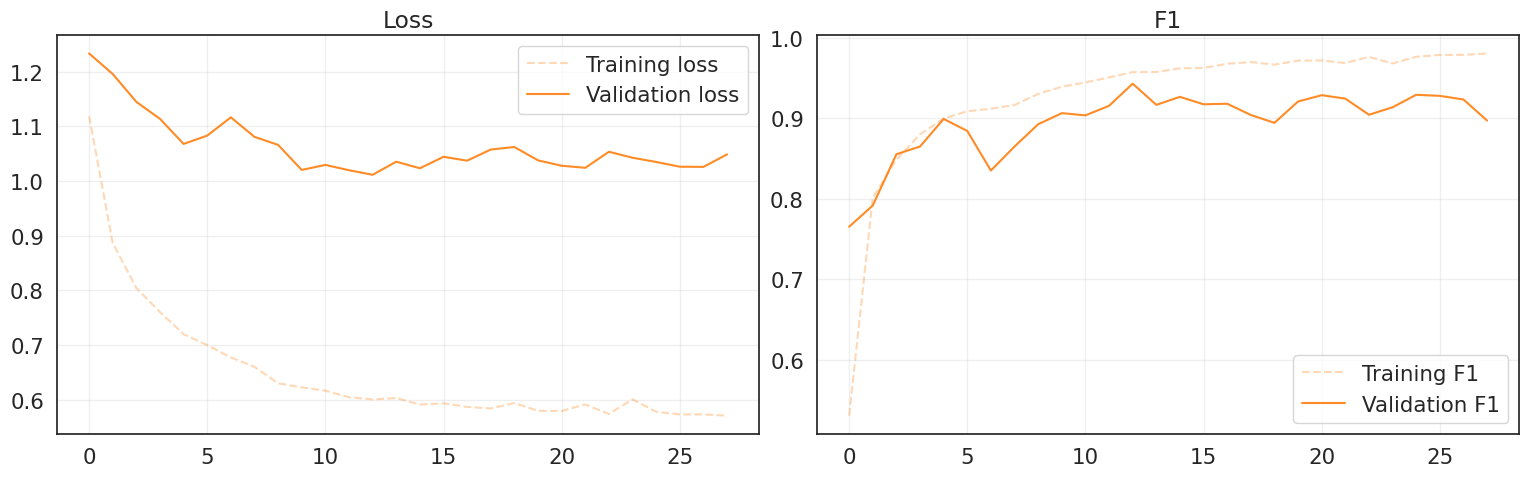

In [36]:
# @title Graph
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## ⏺ **Result**

In [37]:
print(best_model)
print(best_performance)


RecurrentClassifier(
  (rnn): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (classifier): Linear(in_features=256, out_features=3, bias=True)
)
0.9428287817442613


Accuracy over the validation set: 0.9438
Precision over the validation set: 0.9425
Recall over the validation set: 0.9438
F1 score over the validation set: 0.9428


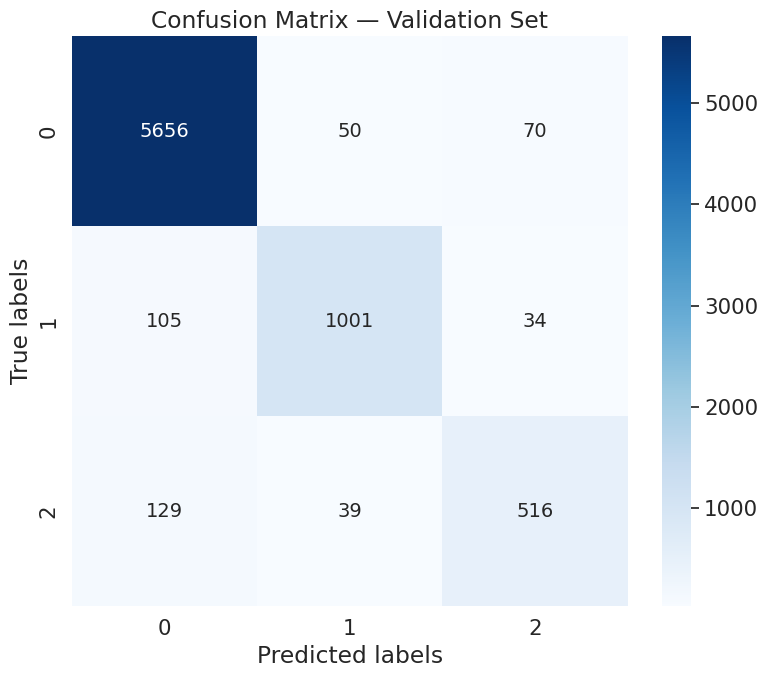

In [41]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
# models = [modelrnn, modelbirnn, modelgruu, modellstm, modelbigru, modelbilstm]
model= best_model
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

##  ⬇**Save Result**

In [38]:
# Collect predictions and ground truth labels
best_model.eval()
test_preds = []
with torch.no_grad():  # Disable gradient computation for inference
    for (xb,) in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        test_preds.append(preds)

test_preds = np.concatenate(test_preds)

test_preds

array([0, 0, 0, ..., 0, 0, 0])

In [39]:
test_preds.shape

(100624,)

In [40]:
df_pred = pd.DataFrame({
    "sample_index": test_ids,
    "pred": test_preds
})

def majority_vote(x):
    counts = np.bincount(x)
    return np.argmax(counts)

final_preds = (    df_pred.groupby("sample_index")["pred"]
    .agg(majority_vote)
    .reset_index()
)

label_map = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
final_preds["label"] = final_preds["pred"].map(label_map)

final_preds.drop(columns=["pred"], inplace=True)
final_preds.to_csv("pirate_predictionsbilstm.csv", index=False)

final_preds

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain
...,...,...
1319,1319,no_pain
1320,1320,no_pain
1321,1321,no_pain
1322,1322,no_pain


## **K-Shuffle-Split Cross Validation**

In [ ]:
def k_shuffle_split_cross_validation_round_rnn(df, epochs, criterion, device,
                            k, n_val_users, n_test_users, batch_size, hidden_layers, hidden_size, learning_rate, dropout_rate,
                            window_size, stride, rnn_type, bidirectional,
                            l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
                            restore_best_weights=True, writer=None, verbose=10, seed=42, experiment_name=""):
    """
    Perform K-fold shuffle split cross-validation with user-based splitting for time series data.

    Args:
        df: DataFrame with columns ['user_id', 'activity', 'x_axis', 'y_axis', 'z_axis', 'id']
        epochs: Number of training epochs
        criterion: Loss function
        device: torch.device for computation
        k: Number of cross-validation splits
        n_val_users: Number of users for validation set
        n_test_users: Number of users for test set
        batch_size: Batch size for training
        hidden_layers: Number of recurrent layers
        hidden_size: Hidden state dimensionality
        learning_rate: Learning rate for optimizer
        dropout_rate: Dropout rate
        window_size: Length of sliding windows
        stride: Step size for sliding windows
        rnn_type: Type of RNN ('RNN', 'LSTM', 'GRU')
        bidirectional: Whether to use bidirectional RNN
        l1_lambda: L1 regularization coefficient (if used)
        l2_lambda: L2 regularization coefficient (weight_decay)
        patience: Early stopping patience
        evaluation_metric: Metric to monitor for early stopping
        mode: 'max' or 'min' for evaluation metric
        restore_best_weights: Whether to restore best weights after training
        writer: TensorBoard writer
        verbose: Verbosity level
        seed: Random seed
        experiment_name: Name for experiment logging

    Returns:
        fold_losses: Dict with validation losses for each split
        fold_metrics: Dict with validation F1 scores for each split
        best_scores: Dict with best F1 score for each split plus mean and std
    """

    # Initialise containers for results across all splits
    fold_losses = {}
    fold_metrics = {}
    best_scores = {}

    df = pd.read_csv("/content/pirate_pain_train.csv")
    target = pd.read_csv("/content/pirate_pain_train_labels.csv")
    test = pd.read_csv("/content/pirate_pain_test.csv")


    df = pd.get_dummies(df)
    test = pd.get_dummies(test)

    df = df.drop(columns=['joint_30'])


    test = test.drop(columns=['joint_30'])

    # Get model architecture parameters
    in_features = input_shape[-1]
    num_classes = len(target['label'].unique())

    # Initialise model architecture
    model = RecurrentClassifier(
        input_size=in_features,
        hidden_size=hidden_size,
        num_layers=hidden_layers,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        rnn_type=rnn_type
    ).to(device)

    # Store initial weights to reset model for each split
    initial_state = copy.deepcopy(model.state_dict())

    # Iterate through K random splits
    for split_idx in range(k):

        if verbose > 0:
            print(f"Split {split_idx+1}/{k}")

        # Get unique user IDs and shuffle them with split-specific seed

        j_cols = [col for col in df.columns if col.startswith('joint_')]
        p_cols = [col for col in df.columns if col.startswith('pain_survey_')]
        t_cols = [col for col in df.columns if col.startswith('tim')]


        df[j_cols] = df[j_cols].astype('float32')
        cols_to_normalize = j_cols + p_cols + t_cols

        # Get unique user IDs and shuffle them with split-specific seed

        unique_users = df['sample_index'].unique()
        random.seed(SEED)
        random.shuffle(unique_users)

        # Calculate the number of users for the training set

        n_train_users = len(unique_users) - N_VAL_USERS - N_TEST_USERS

        # Split the shuffled user IDs into training, validation, and test sets
        train_users = unique_users[:n_train_users]
        val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]
        test_users = unique_users[n_train_users + N_VAL_USERS:]

        # Split the dataset into training, validation, and test sets based on user IDs
        df_train = df[df['sample_index'].isin(train_users)].copy()
        df_val = df[df['sample_index'].isin(val_users)].copy()
        target_train = target[target['sample_index'].isin(train_users)].copy()
        target_val = target[target['sample_index'].isin(val_users)].copy()

        # Define a mapping of activity names to integer labels
        label_mapping = {
          'no_pain': 0,
          'low_pain': 1,
          'high_pain': 2
        }

        # Map activity names to integers in the training set
        target_train['label'] = target_train['label'].map(label_mapping)

        # Map activity names to integers in the validation set
        target_val['label'] = target_val['label'].map(label_mapping)


        if verbose > 0:
            print(f"  Training set shape: {df_train.shape}")
            print(f"  Validation set shape: {df_val.shape}")


        mins = df_train[cols_to_normalize].min()
        maxs = df_train[cols_to_normalize].max()

        for column in cols_to_normalize:
          df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])
          test[column] = (test[column] - mins[column]) / (maxs[column] - mins[column])
          df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])


        # Build sequences using the existing build_sequences function
        # Ensure X_train_static_tiled, X_val_static_tiled, X_test_static_tiled are defined outside or recalculated
        X_train_seq, X_train_static, y_train, X_train_seq_ids = build_sequences2(df_train, target_train, WINDOW_SIZE, STRIDE)
        X_val_seq, X_val_static,  y_val, X_val_seq_ids = build_sequences2(df_val, target_val, WINDOW_SIZE, STRIDE)
        # Note: 'test' DataFrame doesn't have a target, so the label will be None, which is handled in build_sequences
        X_test_seq, X_test_static, _, test_ids = build_sequences2(test, None, WINDOW_SIZE, STRIDE)

        # Re-tiling static features as they depend on the current split's data
        X_train_static_tiled_split = np.repeat(X_train_static[:, None, :], X_train_seq.shape[1], axis=1)
        X_val_static_tiled_split   = np.repeat(X_val_static[:, None, :],   X_val_seq.shape[1], axis=1)
        X_test_static_tiled_split  = np.repeat(X_test_static[:, None, :],  X_test_seq.shape[1], axis=1)

        X_train = np.concatenate([X_train_seq, X_train_static_tiled_split], axis=2)
        X_val   = np.concatenate([X_val_seq,   X_val_static_tiled_split],   axis=2)
        X_test = np.concatenate([X_test_seq,  X_test_static_tiled_split],  axis=2)

        if verbose > 0:
            print(f"  Training sequences shape: {X_train.shape}")
            print(f"  Validation sequences shape: {X_val.shape}")
            print(f"  Test sequences shape: {X_test.shape}")

        # Create PyTorch datasets
        train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).squeeze().long())
        val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).squeeze().long())
        test_ds = TensorDataset(torch.from_numpy(X_test).float())

        # Create data loaders
        train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
        test_loader  = make_loader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

        # Reset model to initial weights for fair comparison across splits
        model.load_state_dict(initial_state)

        # Define optimizer with L2 regularization
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Enable mixed precision training for GPU acceleration
        split_scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Create directory for model checkpoints
        os.makedirs(f"models/{experiment_name}", exist_ok=True)

        # Train model on current split
        model, training_history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            criterion=criterion,
            optimizer=optimizer,
            scaler=split_scaler,
            device=device,
            writer=writer,
            patience=patience,
            verbose=verbose,
            l1_lambda=l1_lambda,
            evaluation_metric=evaluation_metric,
            mode=mode,
            restore_best_weights=restore_best_weights,
            experiment_name=experiment_name+"/split_"+str(split_idx)
        )

        # Store results for this split
        fold_losses[f"split_{split_idx}"] = training_history['val_loss']
        fold_metrics[f"split_{split_idx}"] = training_history['val_f1']
        best_scores[f"split_{split_idx}"] = max(training_history['val_f1'])

    # Compute mean and standard deviation of best scores across splits
    best_scores["mean"] = np.mean([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])
    best_scores["std"] = np.std([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])

    if verbose > 0:
        print(f"Best score: {best_scores['mean']:.4f}±{best_scores['std']:.4f}")

    return fold_losses, fold_metrics, best_scores

In [ ]:
%%time
# Execute K-fold cross-validation with baseline configuration
losses, metrics, best_scores = k_shuffle_split_cross_validation_round_rnn(
    df=df,
    epochs=EPOCHS,
    criterion=criterion,
    device=device,
    k=5,
    batch_size=BATCH_SIZE,
    hidden_layers=HIDDEN_LAYERS,
    hidden_size=HIDDEN_SIZE,
    learning_rate=LEARNING_RATE,
    dropout_rate=DROPOUT_RATE,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    verbose=VERBOSE,
    patience=PATIENCE,
    seed=SEED,
    experiment_name="gru_baseline",
    n_val_users=N_VAL_USERS,
    n_test_users=N_TEST_USERS,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    rnn_type='GRU',
    bidirectional=True
)

Split 1/5
  Training set shape: (84960, 42)
  Validation set shape: (20800, 42)
  Training sequences shape: (40356, 30, 40)
  Validation sequences shape: (9880, 30, 40)
  Test sequences shape: (100624, 30, 40)
Training 200 epochs...
Epoch   1/200 | Train: Loss=1.0244, F1 Score=0.6872 | Val: Loss=1.2950, F1 Score=0.7570
Epoch   2/200 | Train: Loss=0.8124, F1 Score=0.8608 | Val: Loss=1.2150, F1 Score=0.8038
Epoch   3/200 | Train: Loss=0.7231, F1 Score=0.8939 | Val: Loss=1.1848, F1 Score=0.8588
Epoch   4/200 | Train: Loss=0.6710, F1 Score=0.9187 | Val: Loss=1.1535, F1 Score=0.8902
Epoch   5/200 | Train: Loss=0.6613, F1 Score=0.9317 | Val: Loss=1.2046, F1 Score=0.8389
Epoch   6/200 | Train: Loss=0.6294, F1 Score=0.9443 | Val: Loss=1.1562, F1 Score=0.8892
Epoch   7/200 | Train: Loss=0.6224, F1 Score=0.9479 | Val: Loss=1.1496, F1 Score=0.8777
Epoch   8/200 | Train: Loss=0.6150, F1 Score=0.9543 | Val: Loss=1.1312, F1 Score=0.9044
Epoch   9/200 | Train: Loss=0.6077, F1 Score=0.9588 | Val: Loss

In [ ]:
# @title Plot Hitory
# Create figure with two subplots sharing x axis
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5), sharex=True)

# Color palette for K splits
colors = plt.cm.get_cmap('tab10', K)

# Plot validation loss for each split
for split in range(K):
    axes[0].plot(losses[f'split_{split}'][:-PATIENCE], label=f'Split {split+1}',
                 color=colors(split), alpha=0.6)
axes[0].set_title('Validation Loss per Split')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

# Plot validation F1 score for each split
for split in range(K):
    axes[1].plot(metrics[f'split_{split}'][:-PATIENCE], label=f'Split {split+1}',
                 color=colors(split), alpha=0.6)
axes[1].set_title('Validation F1 Score per Split')
axes[1].set_ylabel('F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)

# Add shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.975)
plt.show()

## **Hyperparameters Tuning**

In [ ]:
def grid_search_cv_rnn(df, param_grid, fixed_params, cv_params, verbose=True):
    """
    Execute grid search with K-shuffle-split cross-validation for RNN models on time series data.

    Args:
        df: DataFrame with columns ['user_id', 'activity', 'x_axis', 'y_axis', 'z_axis', 'id']
        param_grid: Dict of parameters to test, e.g. {'batch_size': [16, 32], 'rnn_type': ['LSTM', 'GRU']}
        fixed_params: Dict of fixed hyperparameters (hidden_size, learning_rate, window_size, stride, etc.)
        cv_params: Dict of CV settings (epochs, k, patience, criterion, scaler, device, etc.)
        verbose: Print progress for each configuration

    Returns:
        results: Dict with scores for each configuration
        best_config: Dict with best hyperparameter combination
        best_score: Best mean F1 score achieved
    """
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))

    results = {}
    best_score = -np.inf
    best_config = None

    total = len(combinations)

    for idx, combo in enumerate(combinations, 1):
        # Create current configuration dict
        current_config = dict(zip(param_names, combo))
        config_str = "_".join([f"{k}_{v}" for k, v in current_config.items()])

        if verbose:
            print(f"\nConfiguration {idx}/{total}:")
            for param, value in current_config.items():
                print(f"  {param}: {value}")

        # Merge current config with fixed parameters
        run_params = {**fixed_params, **current_config}

        # Execute cross-validation
        _, _, fold_scores = k_shuffle_split_cross_validation_round_rnn(
            df=df,
            experiment_name=config_str,
            **run_params,
            **cv_params
        )

        # Store results
        results[config_str] = fold_scores

        # Track best configuration
        if fold_scores["mean"] > best_score:
            best_score = fold_scores["mean"]
            best_config = current_config.copy()
            if verbose:
                print("  NEW BEST SCORE!")

        if verbose:
            print(f"  F1 Score: {fold_scores['mean']:.4f}±{fold_scores['std']:.4f}")

    return results, best_config, best_score


def plot_top_configurations_rnn(results, k_splits, top_n=5, figsize=(14, 7)):
    """
    Visualise top N RNN configurations with boxplots of F1 scores across CV splits.

    Args:
        results: Dict of results from grid_search_cv_rnn
        k_splits: Number of CV splits used
        top_n: Number of top configurations to display
        figsize: Figure size tuple
    """
    # Sort by mean score
    config_scores = {name: data['mean'] for name, data in results.items()}
    sorted_configs = sorted(config_scores.items(), key=lambda x: x[1], reverse=True)

    # Select top N
    top_configs = sorted_configs[:min(top_n, len(sorted_configs))]

    # Prepare boxplot data
    boxplot_data = []
    labels = []

    # Define a dictionary for replacements, ordered to handle prefixes correctly
    replacements = {
        'batch_size_': 'BS=',
        'learning_rate_': '\nLR=',
        'hidden_layers_': '\nHL=',
        'hidden_size_': '\nHS=',
        'dropout_rate_': '\nDR=',
        'window_size_': '\nWS=',
        'stride_': '\nSTR=',
        'rnn_type_': '\nRNN=',
        'bidirectional_': '\nBIDIR=',
        'l1_lambda_': '\nL1=',
        'l2_lambda_': '\nL2='
    }

    # Replacements for separators
    separator_replacements = {
        '_learning_rate_': '\nLR=',
        '_hidden_layers_': '\nHL=',
        '_hidden_size_': '\nHS=',
        '_dropout_rate_': '\nDR=',
        '_window_size_': '\nWS=',
        '_stride_': '\nSTR=',
        '_rnn_type_': '\nRNN=',
        '_bidirectional_': '\nBIDIR=',
        '_l1_lambda_': '\nL1=',
        '_l2_lambda_': '\nL2=',
        '_': ''
    }

    for config_name, mean_score in top_configs:
        # Extract best score from each split (auto-detect number of splits)
        split_scores = []
        for i in range(k_splits):
            if f'split_{i}' in results[config_name]:
                split_scores.append(results[config_name][f'split_{i}'])
        boxplot_data.append(split_scores)

        # Verify we have the expected number of splits
        if len(split_scores) != k_splits:
            print(f"Warning: Config {config_name} has {len(split_scores)} splits, expected {k_splits}")

        # Create readable label using the replacements dictionary
        readable_label = config_name
        for old, new in replacements.items():
            readable_label = readable_label.replace(old, new)

        # Apply separator replacements
        for old, new in separator_replacements.items():
             readable_label = readable_label.replace(old, new)

        labels.append(f"{readable_label}\n(μ={mean_score:.3f})")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True)

    # Styling
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

    # Highlight best configuration
    ax.get_xticklabels()[0].set_fontweight('bold')

    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Configuration')
    ax.set_title(f'Top {len(top_configs)} RNN Configurations - F1 Score Distribution Across {k_splits} Splits')
    ax.grid(alpha=0.3, axis='y')

    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

In [ ]:
%%time
K=5
RNN_TYPE='GRU'
BIDIRECTIONAL= True
# Define parameters to search
param_grid = {
    'window_size': [15, 20, 25, 30],
    'stride': [1, 5],
}

# Fixed hyperparameters (not being tuned)
fixed_params = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_size': HIDDEN_SIZE,
    'dropout_rate': DROPOUT_RATE,
    'l1_lambda': L1_LAMBDA,
    'l2_lambda': L2_LAMBDA,
    'rnn_type': RNN_TYPE,
    'bidirectional': BIDIRECTIONAL
}

# Cross-validation settings
cv_params = {
    'epochs': EPOCHS,
    'criterion': criterion,
    'device': device,
    'k': K,
    'n_val_users': N_VAL_USERS,
    'n_test_users': N_TEST_USERS,
    'patience': PATIENCE,
    'verbose': 0,
    'seed': SEED
}

# Execute search
results, best_config, best_score = grid_search_cv_rnn(
    df=df,
    param_grid=param_grid,
    fixed_params=fixed_params,
    cv_params=cv_params
)


Configuration 1/8:
  window_size: 15
  stride: 1
Training 200 epochs...
Early stopping triggered after 25 epochs.
Best model restored from epoch 15 with val_f1 0.9059
Training 200 epochs...
Early stopping triggered after 39 epochs.
Best model restored from epoch 29 with val_f1 0.8708
Training 200 epochs...
Early stopping triggered after 33 epochs.
Best model restored from epoch 23 with val_f1 0.8636
Training 200 epochs...
Early stopping triggered after 38 epochs.
Best model restored from epoch 28 with val_f1 0.8188
Training 200 epochs...
Early stopping triggered after 33 epochs.
Best model restored from epoch 23 with val_f1 0.8904
  NEW BEST SCORE!
  F1 Score: 0.8699±0.0296

Configuration 2/8:
  window_size: 15
  stride: 5
Training 200 epochs...
Early stopping triggered after 35 epochs.
Best model restored from epoch 25 with val_f1 0.8940
Training 200 epochs...
Early stopping triggered after 71 epochs.
Best model restored from epoch 61 with val_f1 0.8871
Training 200 epochs...
Early s

In [ ]:
# Visualise results
plot_top_configurations_rnn(results, k_splits=K, top_n=5)